# GAN for MRI Artifact Reduction (KMAR-50K)
This notebook improves on the baseline GAN. It utilizes a U-Net Generator and a PatchGAN Discriminator to perform Image-to-Image translation from noisy (artifacted) MRI to clean MRI.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import skimage.metrics as metrics
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## 1. Dataset Loader
We load the noisy and clean data, sampling the middle slices safely.

In [ ]:
class KMARDataset(Dataset):
    def __init__(self, root_dir, slice_range=(10, 20), subset_vols=None):
        self.noisy_dir = os.path.join(root_dir, 'ArtifactData')
        self.clean_dir = os.path.join(root_dir, 'GroundTruthData')
        self.slice_range = slice_range
        
        noisy_files = set(os.listdir(self.noisy_dir))
        clean_files = set(os.listdir(self.clean_dir))
        # Intersection of valid nii.gz files
        self.files = [f for f in noisy_files.intersection(clean_files) if f.endswith('.nii.gz')]
        self.files.sort()
        if subset_vols is not None:
            self.files = self.files[:subset_vols]
        
        self.valid_slices = []
        for f in self.files:
            for i in range(self.slice_range[0], self.slice_range[1]):
                self.valid_slices.append((f, i))
        print(f'Total 2D slices extracted: {len(self.valid_slices)}')

    def __len__(self):
        return len(self.valid_slices)

    def preprocess(self, x):
        x = x.astype(np.float32)
        x_min, x_max = x.min(), x.max()
        if x_max > x_min:
            x = (x - x_min) / (x_max - x_min)
        x = torch.tensor(x).unsqueeze(0)
        x = F.interpolate(x.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False).squeeze(0)
        x = x * 2.0 - 1.0
        return x

    def __getitem__(self, idx):
        fname, slice_idx = self.valid_slices[idx]
        noisy_path = os.path.join(self.noisy_dir, fname)
        clean_path = os.path.join(self.clean_dir, fname)
        
        noisy_vol = nib.load(noisy_path).get_fdata()
        clean_vol = nib.load(clean_path).get_fdata()
        
        s_idx = min(slice_idx, noisy_vol.shape[2]-1)
        
        noisy_slice = noisy_vol[:, :, s_idx]
        clean_slice = clean_vol[:, :, s_idx]
        
        return self.preprocess(noisy_slice), self.preprocess(clean_slice)

In [3]:
root_path = '/home/kartik/Desktop/shalini/KMAR-50K'
dataset = KMARDataset(root_path, slice_range=(10, 16), subset_vols=100) # subset for faster iteration
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, drop_last=True)

Total 2D slices extracted: 600


torch.Size([8, 1, 128, 128])


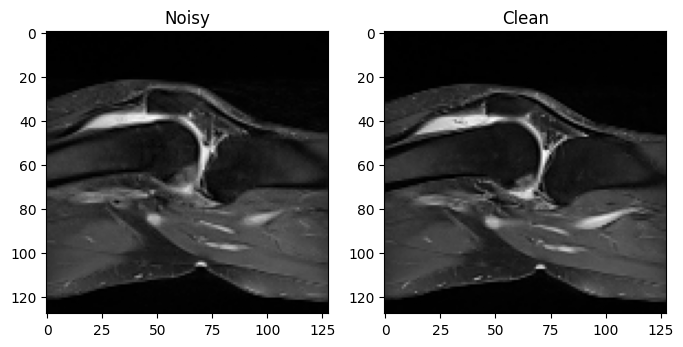

In [4]:
noisy_batch, clean_batch = next(iter(loader))
print(noisy_batch.shape)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title('Noisy')
plt.imshow(noisy_batch[0][0].numpy(), cmap='gray')
plt.subplot(1,2,2)
plt.title('Clean')
plt.imshow(clean_batch[0][0].numpy(), cmap='gray')
plt.show()

## 2. Models: U-Net Generator & PatchGAN Discriminator


In [5]:
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
            
        def up_block(in_c, out_c, drop=0.0):
            layers = [nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
            if drop > 0:
                layers.append(nn.Dropout(drop))
            return nn.Sequential(*layers)

        self.e1 = conv_block(1, 64, norm=False)   # 64x64
        self.e2 = conv_block(64, 128)             # 32x32
        self.e3 = conv_block(128, 256)            # 16x16
        self.e4 = conv_block(256, 512)            # 8x8
        
        self.b = nn.Sequential(nn.Conv2d(512, 512, 4, 2, 1), nn.ReLU(True)) # 4x4
        self.u1 = nn.Sequential(nn.ConvTranspose2d(512, 512, 4, 2, 1), nn.ReLU(True)) # 8x8
        
        self.u2 = up_block(1024, 256)             # 16x16
        self.u3 = up_block(512, 128)              # 32x32
        self.u4 = up_block(256, 64)               # 64x64
        self.final = nn.Sequential(nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1), nn.Tanh()) # 128x128
        
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        b = self.b(e4)
        
        u1 = self.u1(b)
        u2 = self.u2(torch.cat([u1, e4], dim=1))
        u3 = self.u3(torch.cat([u2, e3], dim=1))
        u4 = self.u4(torch.cat([u3, e2], dim=1))
        return self.final(torch.cat([u4, e1], dim=1))

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def d_block(in_c, out_c, stride=2, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
            
        self.net = nn.Sequential(
            d_block(2, 64, norm=False), # No norm in first layer
            d_block(64, 128),
            d_block(128, 256),
            d_block(256, 512, stride=1), # Stride 1 to retain resolution
            nn.Conv2d(512, 1, 4, 1, 1)
        )
        
    def forward(self, x, y):
        # x: input (noisy), y: target/pred (clean/fake)
        return self.net(torch.cat([x, y], dim=1))

In [7]:
G = UNetGenerator().to(device)
D = Discriminator().to(device)

optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

adv_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

## 3. Training & Evaluation


In [8]:
# Helper for evaluation
def evaluate_batch(clean, fake):
    # from [-1, 1] to [0, 1]
    clean = (clean + 1) / 2.0
    fake = (fake + 1) / 2.0
    
    clean_np = clean.cpu().numpy()
    fake_np = fake.cpu().numpy()
    
    psnr_vals = []
    ssim_vals = []
    for i in range(clean.size(0)):
        p = metrics.peak_signal_noise_ratio(clean_np[i,0], fake_np[i,0], data_range=1.0)
        s = metrics.structural_similarity(clean_np[i,0], fake_np[i,0], data_range=1.0)
        psnr_vals.append(p)
        ssim_vals.append(s)
    return np.mean(psnr_vals), np.mean(ssim_vals)

In [9]:
epochs = 10
g_losses, d_losses, psnrs, ssims = [], [], [], []

for e in range(epochs):
    G.train()
    D.train()
    epoch_g_loss = 0
    epoch_d_loss = 0
    
    for batch_idx, (noisy, clean) in enumerate(loader):
        noisy, clean = noisy.to(device), clean.to(device)
        
        # ---- Train Discriminator ----
        optD.zero_grad()
        fake = G(noisy)
        real_pred = D(noisy, clean)
        fake_pred = D(noisy, fake.detach())
        
        loss_d_real = adv_loss(real_pred, torch.ones_like(real_pred))
        loss_d_fake = adv_loss(fake_pred, torch.zeros_like(fake_pred))
        loss_D = (loss_d_real + loss_d_fake) * 0.5
        loss_D.backward()
        optD.step()
        
        # ---- Train Generator ----
        optG.zero_grad()
        fake_pred_g = D(noisy, fake)
        loss_G_adv = adv_loss(fake_pred_g, torch.ones_like(fake_pred_g))
        loss_G_l1 = l1_loss(fake, clean) * 100.0
        loss_G = loss_G_adv + loss_G_l1
        loss_G.backward()
        optG.step()
        
        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        
    g_losses.append(epoch_g_loss / len(loader))
    d_losses.append(epoch_d_loss / len(loader))
    
    # Evaluate
    G.eval()
    with torch.no_grad():
        test_psnr, test_ssim = evaluate_batch(clean, fake)
        psnrs.append(test_psnr)
        ssims.append(test_ssim)
        
    print(f'Epoch [{e+1}/{epochs}] | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f} | PSNR: {test_psnr:.2f} | SSIM: {test_ssim:.4f}')


Epoch [1/10] | G Loss: 22.1458 | D Loss: 0.1932 | PSNR: 19.64 | SSIM: 0.5501
Epoch [2/10] | G Loss: 12.1544 | D Loss: 0.2834 | PSNR: 22.98 | SSIM: 0.6148
Epoch [3/10] | G Loss: 9.6280 | D Loss: 0.5866 | PSNR: 22.69 | SSIM: 0.6458
Epoch [4/10] | G Loss: 10.5084 | D Loss: 0.5076 | PSNR: 24.71 | SSIM: 0.6106
Epoch [5/10] | G Loss: 10.9024 | D Loss: 0.4384 | PSNR: 22.21 | SSIM: 0.6182
Epoch [6/10] | G Loss: 10.9104 | D Loss: 0.4158 | PSNR: 21.52 | SSIM: 0.5447
Epoch [7/10] | G Loss: 11.1581 | D Loss: 0.3929 | PSNR: 23.75 | SSIM: 0.6211
Epoch [8/10] | G Loss: 10.7490 | D Loss: 0.4547 | PSNR: 20.72 | SSIM: 0.6178
Epoch [9/10] | G Loss: 10.8674 | D Loss: 0.3920 | PSNR: 24.54 | SSIM: 0.7305
Epoch [10/10] | G Loss: 10.7104 | D Loss: 0.4872 | PSNR: 21.72 | SSIM: 0.5980


## 4. Visual Analysis & Saving Models


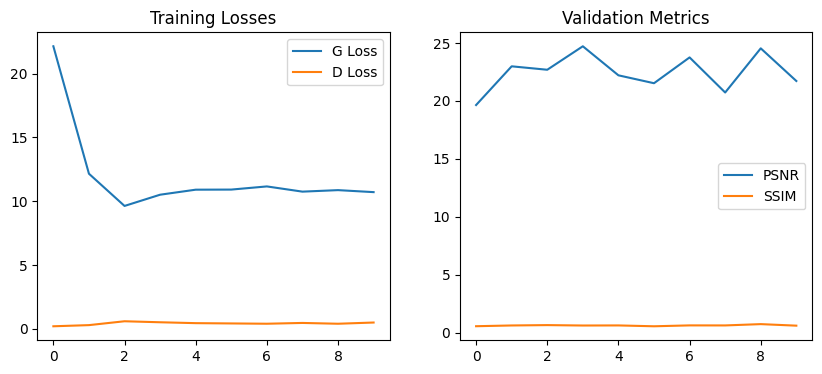

In [10]:
# Plot Losses
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(g_losses, label='G Loss')
plt.plot(d_losses, label='D Loss')
plt.title('Training Losses')
plt.legend()

plt.subplot(1,2,2)
plt.plot(psnrs, label='PSNR')
plt.plot(ssims, label='SSIM')
plt.title('Validation Metrics')
plt.legend()
plt.show()

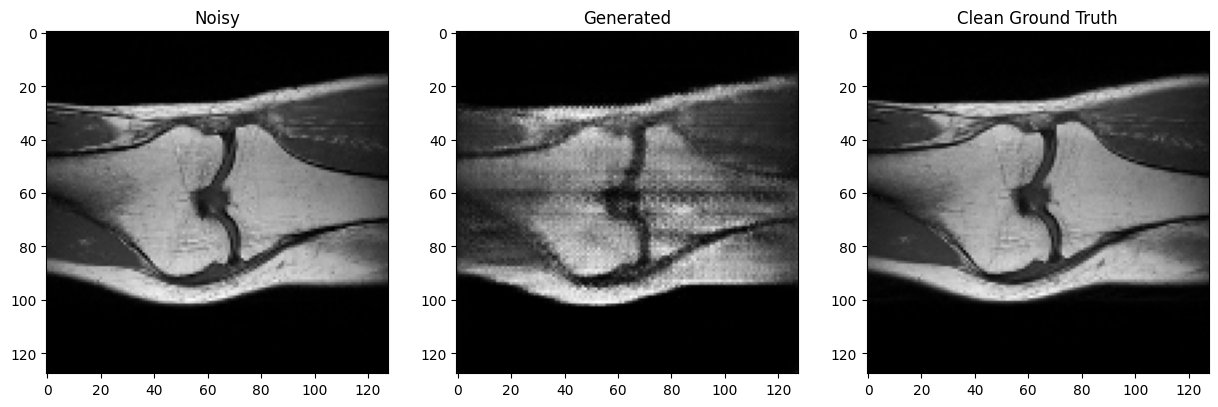

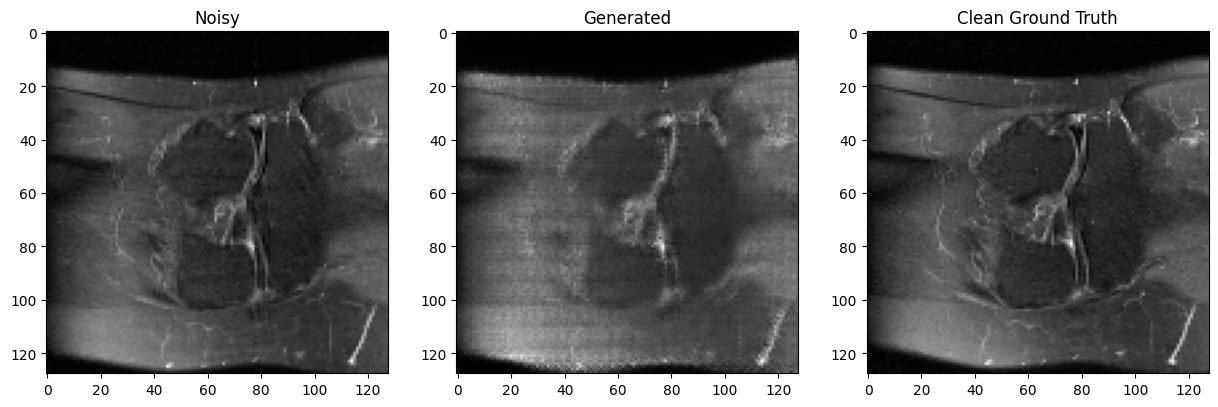

In [11]:
# Visual Result
G.eval()
noisy, clean = next(iter(loader))
noisy, clean = noisy.to(device), clean.to(device)
with torch.no_grad():
    fake = G(noisy)
    
for i in range(2):
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1), plt.imshow(noisy[i][0].cpu().numpy(), cmap='gray'), plt.title('Noisy')
    plt.subplot(1,3,2), plt.imshow(fake[i][0].cpu().numpy(), cmap='gray'), plt.title('Generated')
    plt.subplot(1,3,3), plt.imshow(clean[i][0].cpu().numpy(), cmap='gray'), plt.title('Clean Ground Truth')
    plt.show()

In [12]:
# Save Model
torch.save(G.state_dict(), 'gan_generator.pth')
print('Model saved!')

Model saved!
